# Master PCA visualizations

Diagnostics for the master PCA artifact and 2D comparisons across PCA, TruncatedSVD, t-SNE, and UMAP. This notebook reuses the generated master artifacts and writes only visualization caches under `data/features/viz_cache/`.


In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "UMAP is required for this notebook. Install it with `env/bin/pip install -r requirements.txt`."
    ) from exc

# Make imports robust whether the notebook is launched from repo root or notebooks/reduction.
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing src/ and requirements.txt.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.reduction.build_master_feature_matrix import (
    GENRE_COLUMNS,
    build_binary_block,
    build_numeric_block,
)
from src.reduction.embeddings import (
    EMBEDDING_DIM,
    embedding_columns,
    load_or_create_description_embeddings,
)
from src.reduction.pca import component_block_norm_shares, standardize_and_weight_blocks
from src.utils.io import safe_write_parquet

RANDOM_SEED = 42
SAMPLE_SIZE = 10_000
MULTI_CAP = 3_000

FEATURES_DIR = PROJECT_ROOT / "data" / "features"
VIZ_CACHE = FEATURES_DIR / "viz_cache"
VIZ_CACHE.mkdir(parents=True, exist_ok=True)

GENRE_LABELS = {
    "fantasy": "Fantasy",
    "mystery": "Mystery",
    "history": "History",
    "ya": "Young Adult",
    "romance": "Romance",
    "multi": "Multi-genre",
    "none": "No genre",
}
GENRE_PALETTE = {
    "fantasy": "#4e79a7",
    "mystery": "#f28e2b",
    "history": "#59a14f",
    "ya": "#e15759",
    "romance": "#b07aa1",
    "multi": "#9e9e9e",
    "none": "#bab0ac",
}
MULTI_COLOR = GENRE_PALETTE["multi"]
GENRE_ORDER = ["fantasy", "mystery", "history", "ya", "romance", "multi", "none"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(RANDOM_SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Visualization cache: {VIZ_CACHE}")


Project root: /home/nakato/projects/BigBook
Visualization cache: /home/nakato/projects/BigBook/data/features/viz_cache


## Load artifacts


In [2]:
MASTER_PATH = PROCESSED_DIR / "books_master.parquet"
FEATURE_MATRIX_PATH = FEATURES_DIR / "master_feature_matrix.parquet"
PCA_MODEL_PATH = FEATURES_DIR / "master_pca_model.joblib"
PCA_META_PATH = FEATURES_DIR / "master_pca_meta.json"

required_paths = [
    MASTER_PATH,
    FEATURE_MATRIX_PATH,
    PCA_MODEL_PATH,
    PCA_META_PATH,
    PROJECT_ROOT / "data" / "embeddings" / "description_embeddings.parquet",
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required inputs:\n" + "\n".join(str(path) for path in missing))

master = pd.read_parquet(MASTER_PATH)
feature_matrix = pd.read_parquet(FEATURE_MATRIX_PATH)
pca_artifact = joblib.load(PCA_MODEL_PATH)
meta = json.loads(PCA_META_PATH.read_text(encoding="utf-8"))

master = master.copy()
feature_matrix = feature_matrix.copy()
master["book_id"] = master["book_id"].astype(str)
feature_matrix["book_id"] = feature_matrix["book_id"].astype(str)

master_ids = master["book_id"].reset_index(drop=True)
feature_ids = feature_matrix["book_id"].reset_index(drop=True)
assert set(master_ids) == set(feature_ids), "books_master and feature_matrix have different book_id sets."
assert master_ids.equals(feature_ids), "books_master and feature_matrix are not in the same book_id order."

print(f"Master rows: {len(master):,}")
print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"PCA components: {meta['n_components']}")
print(f"Explained variance sum: {meta['explained_variance_sum']:.6f}")
print(f"Block dims: {pca_artifact['block_dims']}")


Master rows: 108,227
Feature matrix shape: (108227, 174)
PCA components: 173
Explained variance sum: 0.950143
Block dims: {'numeric': 9, 'binary': 11, 'embeddings': 256}


## Stratified sample


In [3]:
def primary_genre(row: pd.Series) -> str:
    if pd.to_numeric(row.get("genre_count"), errors="coerce") >= 2:
        return "multi"
    active = [column.removeprefix("genre_") for column in GENRE_COLUMNS if bool(row.get(column, 0))]
    if len(active) == 1:
        return active[0]
    if len(active) > 1:
        return "multi"
    return "none"


def proportional_counts(counts: pd.Series, target: int, *, multi_cap: int) -> pd.Series:
    available = counts.astype(int).copy()
    if "multi" in available.index:
        available.loc["multi"] = min(int(available.loc["multi"]), multi_cap)

    target = min(target, int(available.sum()))
    raw = available / available.sum() * target
    allocations = np.floor(raw).astype(int)
    allocations = allocations.clip(upper=available)

    remainder = target - int(allocations.sum())
    fractions = (raw - allocations).sort_values(ascending=False)
    while remainder > 0:
        progressed = False
        for group in fractions.index:
            if allocations.loc[group] < available.loc[group]:
                allocations.loc[group] += 1
                remainder -= 1
                progressed = True
                if remainder == 0:
                    break
        if not progressed:
            break
    return allocations[allocations.gt(0)]

master["primary_genre"] = master.apply(primary_genre, axis=1)
counts = master["primary_genre"].value_counts().reindex(GENRE_ORDER).dropna().astype(int)
sample_counts = proportional_counts(counts, SAMPLE_SIZE, multi_cap=MULTI_CAP)

sample_parts = []
for genre, n in sample_counts.items():
    group = master.loc[master["primary_genre"].eq(genre)]
    sample_parts.append(group.sample(n=int(n), random_state=RANDOM_SEED))

sample = (
    pd.concat(sample_parts)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index()
    .rename(columns={"index": "source_idx"})
)
sample["book_id"] = sample["book_id"].astype(str)
sample_idx = sample["source_idx"].to_numpy(dtype=int)
sample_sha1 = hashlib.sha1("\n".join(sample["book_id"]).encode("utf-8")).hexdigest()

print(f"Sample size: {len(sample):,}")
print(f"Sample SHA1: {sample_sha1}")
display(sample["primary_genre"].value_counts().reindex(GENRE_ORDER).dropna().rename("sample_count").to_frame())


Sample size: 10,000
Sample SHA1: 7f470ea4e2ec90fcde770b8515ed67503bd67621


,sample_count
primary_genre,
fantasy,1991.0
mystery,2243.0
history,2009.0
ya,558.0
romance,2860.0
multi,339.0


## Scree and cumulative explained variance


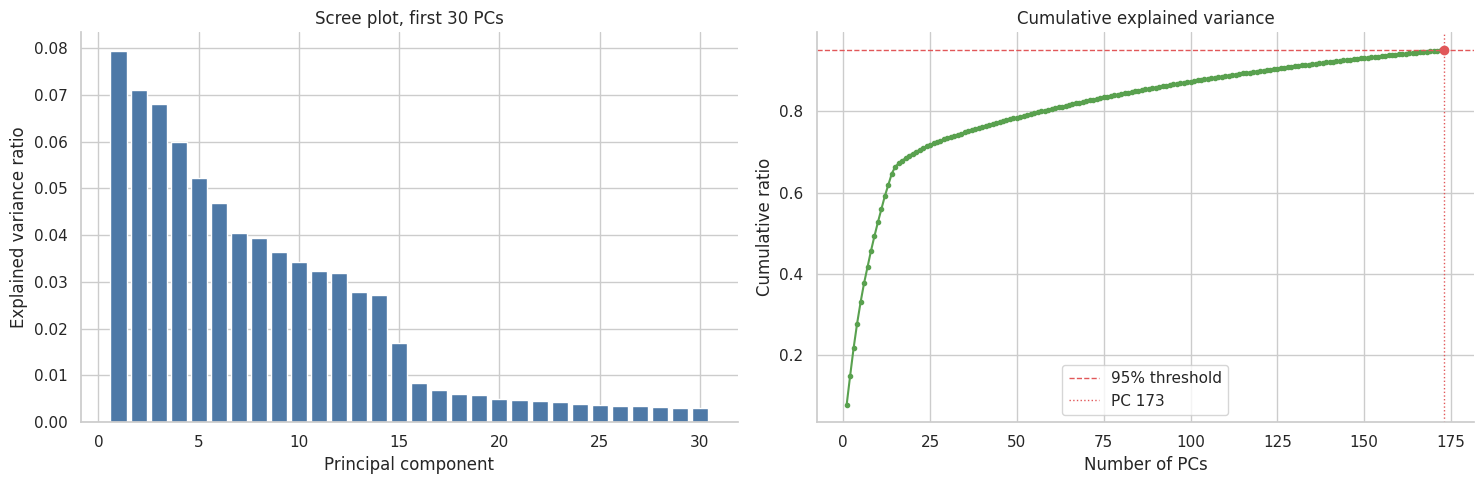

In [4]:
explained = np.asarray(meta["explained_variance_ratio"], dtype=float)
cumulative = explained.cumsum()
first_95 = int(np.argmax(cumulative >= 0.95))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(1, min(30, len(explained)) + 1)
axes[0].bar(x, explained[: len(x)], color="#4e79a7")
axes[0].set_title("Scree plot, first 30 PCs")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", markersize=3, linewidth=1.5, color="#59a14f")
axes[1].axhline(0.95, color="#e15759", linestyle="--", linewidth=1, label="95% threshold")
axes[1].axvline(first_95 + 1, color="#e15759", linestyle=":", linewidth=1, label=f"PC {first_95 + 1}")
axes[1].scatter([first_95 + 1], [cumulative[first_95]], color="#e15759", zorder=3)
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative ratio")
axes[1].legend()

plt.tight_layout()
plt.show()


## Block norm shares, first 5 PCs


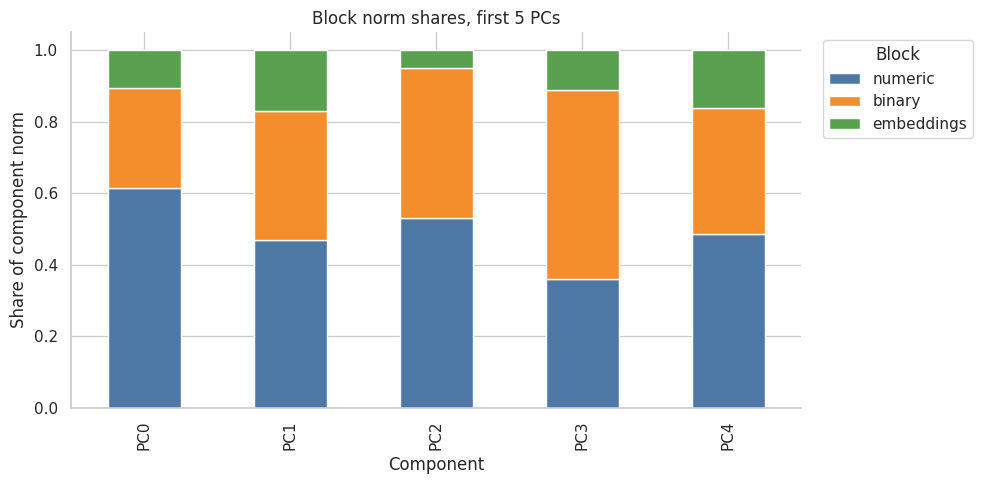

,numeric,binary,embeddings
PC0,0.614,0.279,0.107
PC1,0.470,0.360,0.170
PC2,0.530,0.420,0.050
PC3,0.361,0.527,0.112
PC4,0.485,0.353,0.163


In [5]:
first5 = meta["component_block_norm_shares_first_5"]
share_df = pd.DataFrame(
    [summary["block_norm_shares"] for summary in first5],
    index=[f"PC{summary['component']}" for summary in first5],
)
share_df = share_df[[column for column in ["numeric", "binary", "embeddings"] if column in share_df.columns]]

ax = share_df.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#4e79a7", "#f28e2b", "#59a14f"])
ax.set_title("Block norm shares, first 5 PCs")
ax.set_xlabel("Component")
ax.set_ylabel("Share of component norm")
ax.legend(title="Block", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(share_df.round(3))


## Block norm heatmap, first 20 PCs


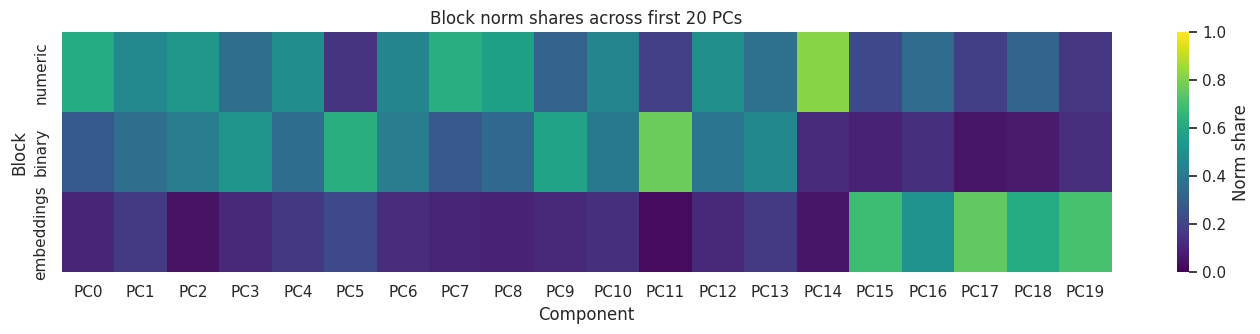

In [6]:
block_summaries_20 = component_block_norm_shares(
    pca_artifact["pca"],
    pca_artifact["block_slices"],
    first_n=20,
)
heatmap_df = pd.DataFrame(
    [summary["block_norm_shares"] for summary in block_summaries_20],
    index=[f"PC{summary['component']}" for summary in block_summaries_20],
).T

plt.figure(figsize=(14, 3.5))
sns.heatmap(heatmap_df, cmap="viridis", vmin=0, vmax=1, annot=False, cbar_kws={"label": "Norm share"})
plt.title("Block norm shares across first 20 PCs")
plt.xlabel("Component")
plt.ylabel("Block")
plt.tight_layout()
plt.show()


## Top non-embedding loadings


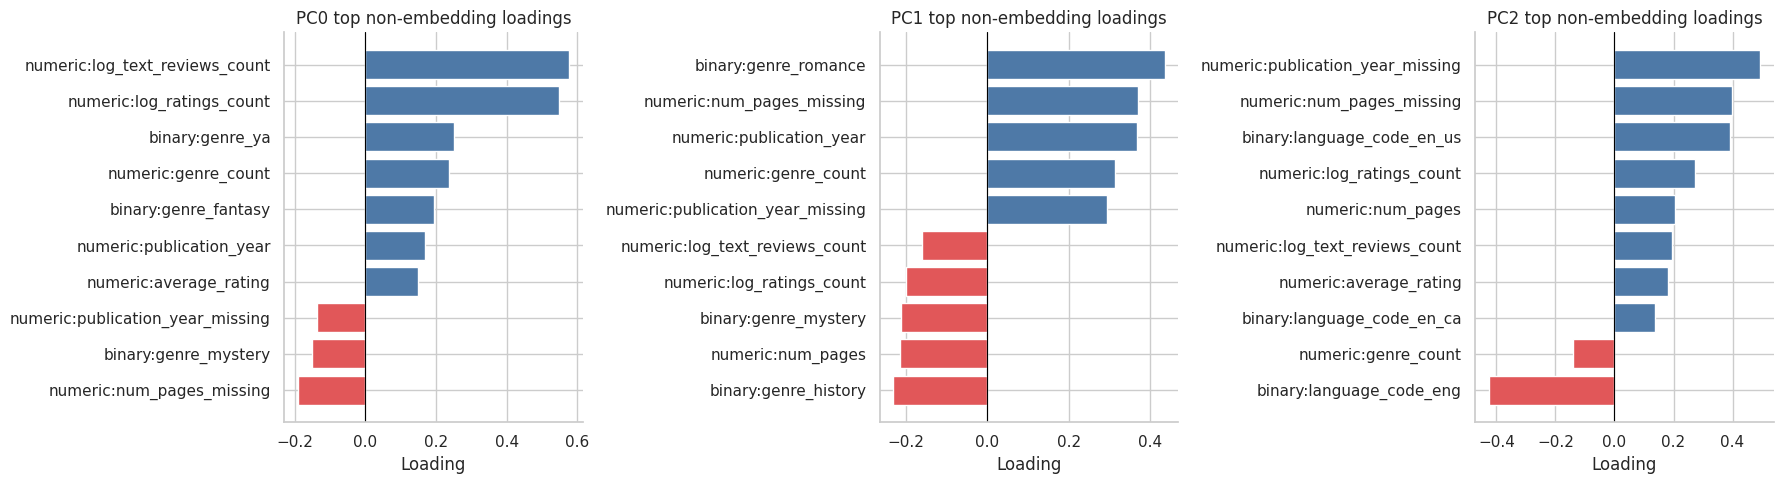

In [7]:
def top_non_embedding_loadings(component_idx: int, top_n: int = 10) -> pd.DataFrame:
    component = pca_artifact["pca"].components_[component_idx]
    rows = []
    for block_name in ["numeric", "binary"]:
        start, end = pca_artifact["block_slices"][block_name]
        columns = pca_artifact["block_columns"][block_name]
        for column, loading in zip(columns, component[start:end]):
            rows.append({"feature": f"{block_name}:{column}", "loading": float(loading), "abs_loading": abs(float(loading))})
    return pd.DataFrame(rows).nlargest(top_n, "abs_loading").sort_values("loading")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
for component_idx, ax in enumerate(axes):
    top_df = top_non_embedding_loadings(component_idx)
    colors = np.where(top_df["loading"].ge(0), "#4e79a7", "#e15759")
    ax.barh(top_df["feature"], top_df["loading"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"PC{component_idx} top non-embedding loadings")
    ax.set_xlabel("Loading")
plt.tight_layout()
plt.show()


## PCA 2D scatter


In [8]:
pca_points = sample[["book_id", "title", "primary_genre"]].merge(
    feature_matrix[["book_id", "pc_0", "pc_1"]],
    on="book_id",
    how="left",
    validate="one_to_one",
)
assert pca_points[["pc_0", "pc_1"]].notna().all().all()

fig = px.scatter(
    pca_points,
    x="pc_0",
    y="pc_1",
    color="primary_genre",
    category_orders={"primary_genre": GENRE_ORDER},
    color_discrete_map=GENRE_PALETTE,
    hover_data={"title": True, "book_id": True, "primary_genre": True, "pc_0": ":.3f", "pc_1": ":.3f"},
    labels={"primary_genre": "Genre", "pc_0": "PC0", "pc_1": "PC1"},
    title="Master PCA, first two components",
    render_mode="webgl",
    width=950,
    height=650,
)
fig.update_traces(marker={"size": 5, "opacity": 0.72})
fig.show()


## Rebuild scaled matrix X


In [9]:
numeric_block, _numeric_medians = build_numeric_block(master)
binary_block, lang_categories = build_binary_block(master, lang_categories=pca_artifact["lang_categories"])
embeddings = load_or_create_description_embeddings(master)
embedding_block = embeddings[embedding_columns(EMBEDDING_DIM)]

scaled = standardize_and_weight_blocks(
    {
        "numeric": numeric_block,
        "binary": binary_block,
        "embeddings": embedding_block,
    }
)
X = scaled.matrix

expected_dim = sum(pca_artifact["block_dims"].values())
assert X.shape[0] == len(master)
assert X.shape[1] == expected_dim, f"Expected {expected_dim} columns, got {X.shape[1]}."
assert scaled.block_dims == pca_artifact["block_dims"]

print(f"X shape: {X.shape}")
print(f"X dtype: {X.dtype}")
print(f"Block dims: {scaled.block_dims}")
print(f"Language categories: {lang_categories}")


Embedding cache covers all 108,227 books: /home/nakato/projects/BigBook/data/embeddings/description_embeddings.parquet
X shape: (108227, 276)
X dtype: float32
Block dims: {'numeric': 9, 'binary': 11, 'embeddings': 256}
Language categories: ['eng', 'en-US', 'en-GB', 'en-CA']


## PCA(50) pre-whitening for nonlinear reducers


In [10]:
pca50_path = VIZ_CACHE / "pca50.npy"
pca50_meta_path = VIZ_CACHE / "pca50_meta.json"
pca50_meta = {"seed": RANDOM_SEED, "n_components": 50, "sample_sha1": sample_sha1}

if pca50_path.exists() and pca50_meta_path.exists() and json.loads(pca50_meta_path.read_text(encoding="utf-8")) == pca50_meta:
    X_50 = np.load(pca50_path)
    print(f"Loaded cached PCA(50): {pca50_path}")
else:
    X_50 = PCA(n_components=50, random_state=RANDOM_SEED).fit_transform(X[sample_idx]).astype("float32")
    np.save(pca50_path, X_50)
    pca50_meta_path.write_text(json.dumps(pca50_meta, indent=2), encoding="utf-8")
    print(f"Wrote PCA(50) cache: {pca50_path}")

assert X_50.shape == (len(sample), 50)
print(f"X_50 shape: {X_50.shape}")


Loaded cached PCA(50): /home/nakato/projects/BigBook/data/features/viz_cache/pca50.npy
X_50 shape: (10000, 50)


## TruncatedSVD 2D scatter


In [11]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
svd_full = svd.fit_transform(X).astype("float32")
svd_points = sample[["book_id", "title", "primary_genre"]].copy()
svd_points["svd_x"] = svd_full[sample_idx, 0]
svd_points["svd_y"] = svd_full[sample_idx, 1]

print(f"SVD explained variance ratio sum: {svd.explained_variance_ratio_.sum():.4f}")

fig = px.scatter(
    svd_points,
    x="svd_x",
    y="svd_y",
    color="primary_genre",
    category_orders={"primary_genre": GENRE_ORDER},
    color_discrete_map=GENRE_PALETTE,
    hover_data={"title": True, "book_id": True, "primary_genre": True, "svd_x": ":.3f", "svd_y": ":.3f"},
    labels={"primary_genre": "Genre", "svd_x": "SVD 0", "svd_y": "SVD 1"},
    title="TruncatedSVD on scaled master matrix",
    render_mode="webgl",
    width=950,
    height=650,
)
fig.update_traces(marker={"size": 5, "opacity": 0.72})
fig.show()


SVD explained variance ratio sum: 0.1506


## t-SNE 2D with cache


In [12]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def cache_matches(meta_path: Path, expected: dict) -> bool:
    return meta_path.exists() and read_json(meta_path) == expected


def plot_cached_scatter(points: pd.DataFrame, x: str, y: str, title: str):
    fig = px.scatter(
        points,
        x=x,
        y=y,
        color="primary_genre",
        category_orders={"primary_genre": GENRE_ORDER},
        color_discrete_map=GENRE_PALETTE,
        hover_data={"title": True, "book_id": True, "primary_genre": True, x: ":.3f", y: ":.3f"},
        labels={"primary_genre": "Genre"},
        title=title,
        render_mode="webgl",
        width=950,
        height=650,
    )
    fig.update_traces(marker={"size": 5, "opacity": 0.72})
    fig.show()

TSNE_PERPLEXITY = 30
TSNE_MAX_ITER = 1000
tsne_path = VIZ_CACHE / "tsne_2d.parquet"
tsne_meta_path = VIZ_CACHE / "tsne_meta.json"
tsne_meta = {
    "seed": RANDOM_SEED,
    "perplexity": TSNE_PERPLEXITY,
    "max_iter": TSNE_MAX_ITER,
    "sample_sha1": sample_sha1,
}

if tsne_path.exists() and cache_matches(tsne_meta_path, tsne_meta):
    tsne_points = pd.read_parquet(tsne_path)
    tsne_points["book_id"] = tsne_points["book_id"].astype(str)
    print(f"Loaded cached t-SNE: {tsne_path}")
else:
    tsne = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        max_iter=TSNE_MAX_ITER,
        init="pca",
        learning_rate="auto",
        random_state=RANDOM_SEED,
    )
    tsne_xy = tsne.fit_transform(X_50).astype("float32")
    tsne_points = pd.DataFrame(
        {
            "book_id": sample["book_id"].to_numpy(),
            "tsne_x": tsne_xy[:, 0],
            "tsne_y": tsne_xy[:, 1],
        }
    )
    safe_write_parquet(tsne_points, tsne_path)
    tsne_meta_path.write_text(json.dumps(tsne_meta, indent=2), encoding="utf-8")
    print(f"Wrote t-SNE cache: {tsne_path}")

tsne_points = sample[["book_id", "title", "primary_genre"]].merge(tsne_points, on="book_id", how="left", validate="one_to_one")
assert tsne_points[["tsne_x", "tsne_y"]].notna().all().all()
plot_cached_scatter(tsne_points, "tsne_x", "tsne_y", "t-SNE on PCA(50) sample")


Loaded cached t-SNE: /home/nakato/projects/BigBook/data/features/viz_cache/tsne_2d.parquet


## UMAP 2D with cache


In [13]:
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.1
umap_path = VIZ_CACHE / "umap_2d.parquet"
umap_meta_path = VIZ_CACHE / "umap_meta.json"
umap_meta = {
    "seed": RANDOM_SEED,
    "n_neighbors": UMAP_N_NEIGHBORS,
    "min_dist": UMAP_MIN_DIST,
    "sample_sha1": sample_sha1,
}

if umap_path.exists() and cache_matches(umap_meta_path, umap_meta):
    umap_points = pd.read_parquet(umap_path)
    umap_points["book_id"] = umap_points["book_id"].astype(str)
    print(f"Loaded cached UMAP: {umap_path}")
else:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_SEED,
    )
    umap_xy = reducer.fit_transform(X_50).astype("float32")
    umap_points = pd.DataFrame(
        {
            "book_id": sample["book_id"].to_numpy(),
            "umap_x": umap_xy[:, 0],
            "umap_y": umap_xy[:, 1],
        }
    )
    safe_write_parquet(umap_points, umap_path)
    umap_meta_path.write_text(json.dumps(umap_meta, indent=2), encoding="utf-8")
    print(f"Wrote UMAP cache: {umap_path}")

umap_points = sample[["book_id", "title", "primary_genre"]].merge(umap_points, on="book_id", how="left", validate="one_to_one")
assert umap_points[["umap_x", "umap_y"]].notna().all().all()
plot_cached_scatter(umap_points, "umap_x", "umap_y", "UMAP on PCA(50) sample")


Loaded cached UMAP: /home/nakato/projects/BigBook/data/features/viz_cache/umap_2d.parquet


## 2x2 comparison figure


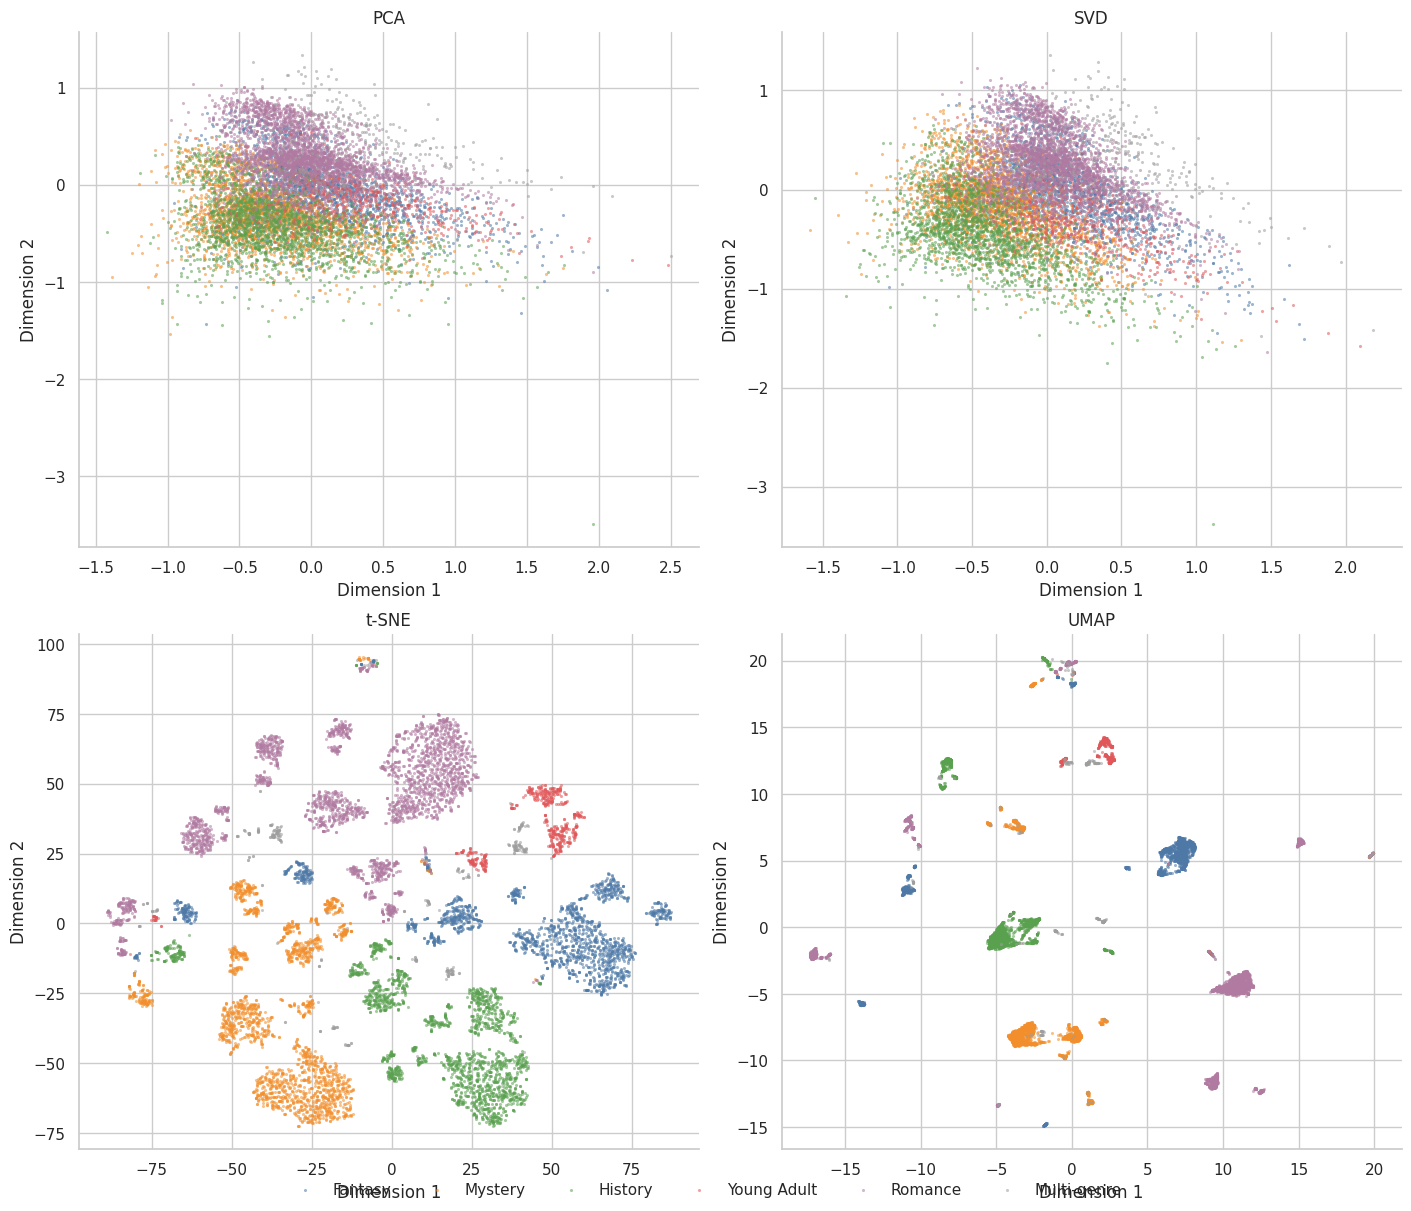

In [14]:
comparison_frames = {
    "PCA": pca_points.rename(columns={"pc_0": "x", "pc_1": "y"})[["book_id", "primary_genre", "x", "y"]],
    "SVD": svd_points.rename(columns={"svd_x": "x", "svd_y": "y"})[["book_id", "primary_genre", "x", "y"]],
    "t-SNE": tsne_points.rename(columns={"tsne_x": "x", "tsne_y": "y"})[["book_id", "primary_genre", "x", "y"]],
    "UMAP": umap_points.rename(columns={"umap_x": "x", "umap_y": "y"})[["book_id", "primary_genre", "x", "y"]],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, (name, points) in zip(axes, comparison_frames.items()):
    for genre in GENRE_ORDER:
        subset = points.loc[points["primary_genre"].eq(genre)]
        if subset.empty:
            continue
        ax.scatter(
            subset["x"],
            subset["y"],
            s=5,
            alpha=0.55,
            c=GENRE_PALETTE.get(genre, "#333333"),
            label=GENRE_LABELS.get(genre, genre),
            linewidths=0,
        )
    ax.set_title(name)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 7), frameon=False)
plt.show()


## Semantic spot-check overlay


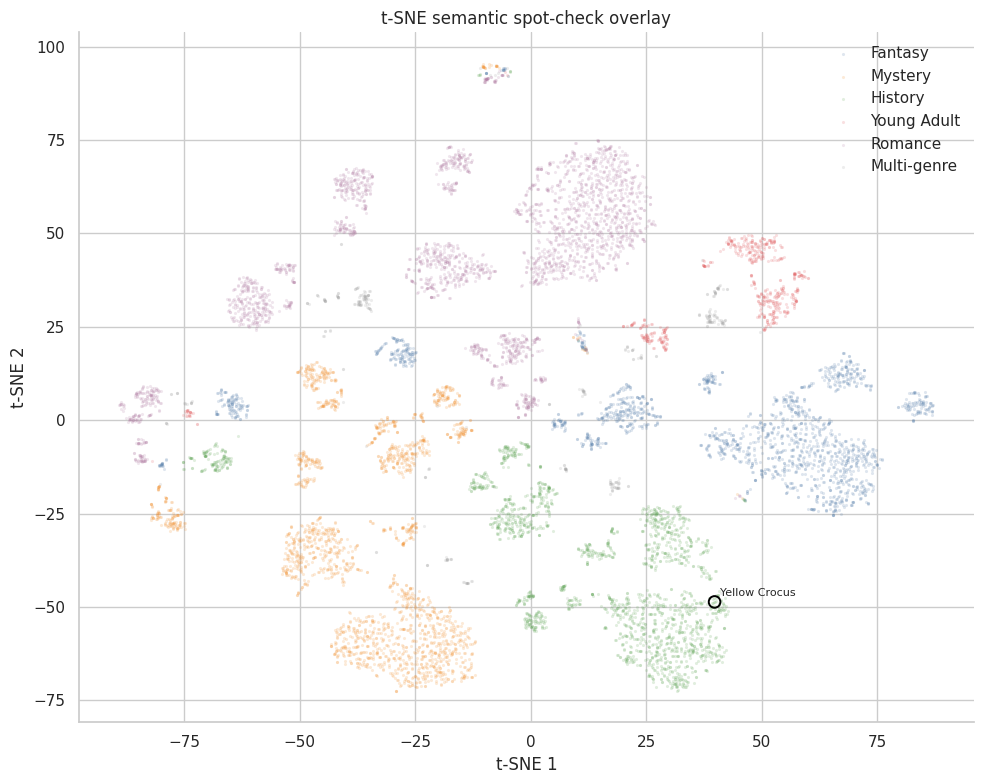

,book_id,title,primary_genre,tsne_x,tsne_y
5943,10000191,Yellow Crocus,history,39.826187,-48.617756


In [15]:
spot_checks = meta.get("semantic_spot_checks", [])
spot_ids = []
for check in spot_checks:
    spot_ids.extend(check.get("same_genre_books", []))
    spot_ids.append(check.get("different_genre_book"))
spot_ids = [str(book_id) for book_id in spot_ids if book_id is not None]
spot_id_set = set(spot_ids)

spot_points = tsne_points.loc[tsne_points["book_id"].isin(spot_id_set)].copy()
if spot_points.empty:
    print("None of the semantic spot-check book_ids are present in this sample. Re-run with a larger sample or force-include these ids if annotation is needed.")
else:
    fig, ax = plt.subplots(figsize=(10, 8))
    for genre in GENRE_ORDER:
        subset = tsne_points.loc[tsne_points["primary_genre"].eq(genre)]
        if subset.empty:
            continue
        ax.scatter(
            subset["tsne_x"],
            subset["tsne_y"],
            s=5,
            alpha=0.18,
            c=GENRE_PALETTE.get(genre, "#333333"),
            label=GENRE_LABELS.get(genre, genre),
            linewidths=0,
        )

    ax.scatter(spot_points["tsne_x"], spot_points["tsne_y"], s=70, facecolors="none", edgecolors="black", linewidths=1.4)
    for _, row in spot_points.iterrows():
        title = str(row.get("title", row["book_id"]))[:36]
        ax.annotate(title, (row["tsne_x"], row["tsne_y"]), xytext=(4, 4), textcoords="offset points", fontsize=8)

    ax.set_title("t-SNE semantic spot-check overlay")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc="best", frameon=False)
    plt.tight_layout()
    plt.show()

    display(spot_points[["book_id", "title", "primary_genre", "tsne_x", "tsne_y"]])


## Reproducibility footer


In [16]:
def git_sha(root: Path) -> str | None:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=root, text=True).strip()
    except Exception:
        return None

run_meta = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "seed": RANDOM_SEED,
    "sample_size": int(len(sample)),
    "sample_sha1": sample_sha1,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": sklearn_version,
    "umap_version": getattr(umap, "__version__", "unknown"),
    "git_sha": git_sha(PROJECT_ROOT),
    "pca_artifact_path": str(PCA_MODEL_PATH),
    "pca_meta_path": str(PCA_META_PATH),
}
run_meta_path = VIZ_CACHE / "run_meta.json"
run_meta_path.write_text(json.dumps(run_meta, indent=2), encoding="utf-8")

print(json.dumps(run_meta, indent=2))
print(f"Wrote run metadata: {run_meta_path}")


{
  "created_at_utc": "2026-05-09T21:28:04.378916+00:00",
  "project_root": "/home/nakato/projects/BigBook",
  "seed": 42,
  "sample_size": 10000,
  "sample_sha1": "7f470ea4e2ec90fcde770b8515ed67503bd67621",
  "numpy_version": "2.4.4",
  "pandas_version": "3.0.2",
  "sklearn_version": "1.8.0",
  "umap_version": "0.5.12",
  "git_sha": "3f8b5b39b40f5b33989818fbf7518aa9ae24b430",
  "pca_artifact_path": "/home/nakato/projects/BigBook/data/features/master_pca_model.joblib",
  "pca_meta_path": "/home/nakato/projects/BigBook/data/features/master_pca_meta.json"
}
Wrote run metadata: /home/nakato/projects/BigBook/data/features/viz_cache/run_meta.json
